In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
%reset -f

## Create data subtset:
This was done manually by using the script below to manually sort the shoes into the personality-based categories.

Sorting occurred until the point that each category had a minimum of 50 images.

In [24]:
import random
import os
import shutil
from IPython.display import Image, display

# Ensure base_dir, categories, and image_extensions are defined from previous cells
base_dir = '/content/drive/MyDrive/UBC Year 5 2025 26/MANU 465/ShoesDataset'
categories = ['classic', 'casual', 'stylish', 'practical']
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff')

classified_count = 0

# Create a mapping from integer strings to categories for easy lookup
int_to_category_map = {str(i+1): cat.lower() for i, cat in enumerate(categories)}
valid_category_names = [cat.lower() for cat in categories]

# Pre-calculate category paths for efficient checking
category_paths = [os.path.join(base_dir, cat) + os.sep for cat in categories]

while True:
    print("\n--- Starting new classification round ---")

    # 3. Clear and re-populate unclassified_images for each round
    unclassified_images = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                image_full_path = os.path.join(root, file)

                is_classified = False
                for cat_path_prefix in category_paths:
                    if image_full_path.startswith(cat_path_prefix):
                        is_classified = True
                        break

                if not is_classified:
                    unclassified_images.append(image_full_path)

    # 4. Check if the unclassified_images list is empty
    if not unclassified_images:
        print(f"No more unclassified image files found in '{base_dir}' or its subfolders (excluding classified category folders).")
        break # Exit loop if no images are left

    # 5. Randomly select one image file and display it
    selected_image_path = random.choice(unclassified_images)
    print(f"Selected image for classification: \n{selected_image_path}")
    display(Image(filename=selected_image_path, width=400))

    # 6. Prompt the user for classification input with validation
    user_classification_choice = None
    prompt_options_str = ", ".join([f"{i+1}:{cat}" for i, cat in enumerate(categories)]) # Shortened prompt

    while user_classification_choice is None:
        print(f"Enter one of {prompt_options_str} or 'skip' to skip: ")
        user_input_raw = input().strip().lower()
        if user_input_raw in valid_category_names:
            user_classification_choice = user_input_raw
            print(f"You entered: {user_classification_choice}")
        elif user_input_raw in int_to_category_map:
            user_classification_choice = int_to_category_map[user_input_raw]
            print(f"You entered: {user_classification_choice} ({categories[int(user_input_raw)-1].lower()})")
        elif user_input_raw == 'skip':
            user_classification_choice = 'skip'
            print(f"You entered: {user_input_raw}")
        else:
            print("Invalid input. Please try again.")

    # 7. Move image to category folder or print 'skipped' message
    if user_classification_choice == 'skip':
        print(f"Image skipped: {os.path.basename(selected_image_path)}. No action taken.")
    else:
        try:
            destination_folder = os.path.join(base_dir, user_classification_choice)
            os.makedirs(destination_folder, exist_ok=True)
            new_image_path = os.path.join(destination_folder, os.path.basename(selected_image_path))
            shutil.move(selected_image_path, new_image_path)
            print(f"Image successfully moved to: {new_image_path}")
            classified_count += 1
        except FileNotFoundError:
            print(f"Error: Source image not found at {selected_image_path}")
        except PermissionError:
            print(f"Error: Permission denied. Cannot move image to {new_image_path}")
        except Exception as e:
            print(f"An unexpected error occurred while moving the image: {e}")

    # 8. Ask the user if they want to classify another image (empty input means yes)
    continue_classification = input("Classify another image? (Press Enter for yes, type 'no' to stop): ").strip().lower()
    if continue_classification == 'no': # Only 'no' stops the process
        print("\nClassification process ended by user.")
        break

print(f"Total images classified in this session: {classified_count}")


--- Starting new classification round ---


KeyboardInterrupt: 

Before running the rest of this script, the images were copied over to the working folder.

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os

# Path to your dataset
data_dir = '/content/drive/MyDrive/UBC Year 5 2025 26/MANU 465/Sorted_ShoesDataset'

In [26]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Define separate transforms for training (with augmentation) and testing
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load the dataset twice to apply different transforms to the splits
full_dataset_train = datasets.ImageFolder(data_dir, transform=train_transform)
full_dataset_test = datasets.ImageFolder(data_dir, transform=test_transform)

# Create the indices for the split
dataset_size = len(full_dataset_train)
indices = list(range(dataset_size))
train_size = int(0.8 * dataset_size)

import random
random.seed(42)
random.shuffle(indices)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create subsets using the corresponding transforms
train_dataset = Subset(full_dataset_train, train_indices)
test_dataset = Subset(full_dataset_test, test_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = full_dataset_train.classes
print(f'Classes found: {class_names}')
print(f'Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}')

Classes found: ['Casual', 'Classic', 'Practical', 'Stylish']
Training samples: 288, Test samples: 73


In [27]:
class ShoeCNN(nn.Module):
    def __init__(self, num_classes):
        super(ShoeCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ShoeCNN(len(class_names))
print(model)

ShoeCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [28]:
# Training and Evaluation with history tracking
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 35
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Dictionary to store history for plotting
history = {'loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    history['loss'].append(epoch_loss)

    # Evaluation at the end of each epoch for the curve
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    history['test_acc'].append(test_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Test Acc: {test_acc:.2f}%')

print(f'Final accuracy on test set: {history["test_acc"][-1]:.2f}%')

Epoch 1/35, Loss: 5.5725, Test Acc: 41.10%
Epoch 2/35, Loss: 1.4824, Test Acc: 30.14%
Epoch 3/35, Loss: 1.3556, Test Acc: 42.47%
Epoch 4/35, Loss: 1.3377, Test Acc: 39.73%
Epoch 5/35, Loss: 1.2900, Test Acc: 43.84%
Epoch 6/35, Loss: 1.2528, Test Acc: 47.95%
Epoch 7/35, Loss: 1.2046, Test Acc: 53.42%
Epoch 8/35, Loss: 1.1183, Test Acc: 38.36%
Epoch 9/35, Loss: 1.1097, Test Acc: 52.05%
Epoch 10/35, Loss: 1.0233, Test Acc: 43.84%
Epoch 11/35, Loss: 0.9684, Test Acc: 47.95%
Epoch 12/35, Loss: 0.9167, Test Acc: 53.42%
Epoch 13/35, Loss: 0.8347, Test Acc: 50.68%
Epoch 14/35, Loss: 0.8367, Test Acc: 54.79%
Epoch 15/35, Loss: 0.7004, Test Acc: 61.64%
Epoch 16/35, Loss: 0.6770, Test Acc: 60.27%
Epoch 17/35, Loss: 0.6371, Test Acc: 50.68%
Epoch 18/35, Loss: 0.6379, Test Acc: 57.53%
Epoch 19/35, Loss: 0.5380, Test Acc: 67.12%
Epoch 20/35, Loss: 0.5691, Test Acc: 54.79%
Epoch 21/35, Loss: 0.5004, Test Acc: 61.64%
Epoch 22/35, Loss: 0.4837, Test Acc: 58.90%
Epoch 23/35, Loss: 0.4132, Test Acc: 49.3

## Model Accuracy

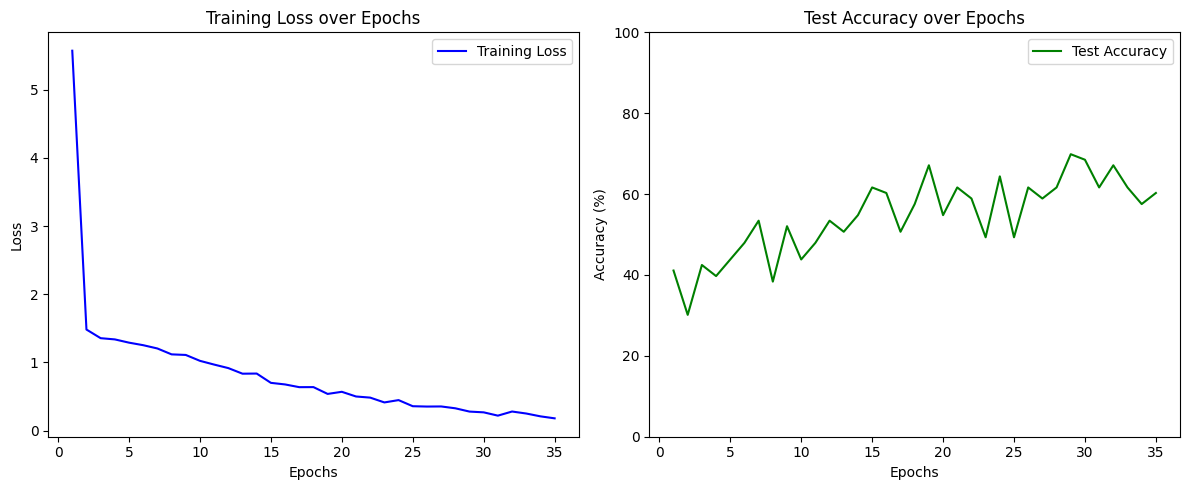

In [29]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    epochs = range(1, len(history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Training Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Test Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['test_acc'], 'g-', label='Test Accuracy')
    plt.title('Test Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.ylim(0, 100)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Check if history exists from the previous training cell
if 'history' in locals():
    plot_training_results(history)
else:
    print('Training history not found. Please ensure the training cell has finished executing.')

Despite the losses being reduced heavily over the course of 35 epochs, the accuracy remained limited (60.3%). This could be partially attributed to the arbitrary nature of my categories. Often even I had trouble classifying the footwear. When I asked friends to do some classification, sometimes we disagreed on the personality of the shoes.

To me, this exercise demonstrated how tough it is to assign personalities to objects.


Results may have improved with a larger test set (part of why I added the data augmentation step). Adding more epochs might've improved it slightly, though it would risk overfitting the model. But I could have also picked more defined personality categories.